In [38]:
import sys
import torch

print("Python Version:", sys.version)
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

Python Version: 3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]
PyTorch Version: 2.10.0+cu126
CUDA Available: True


# Spatio-Temporal Forecasting of Municipal EV Charging Load  
## MODEL COMPARISON v3  

Models compared:
1. Simple RNN  *(Baseline)*
2. LSTM  *(Baseline)*
3. Transformer (encoder-only)  *(Baseline)*
4. **Transformer-LSTM ← Proposed (Best)**


## Imports & Setup

In [13]:
"""
============================================================
Spatio-Temporal Forecasting of Municipal EV Charging Load
MODEL COMPARISON  v4  ← UPDATED (error-reduced)
============================================================
Key changes from v3:
  ✔ HuberLoss instead of L1Loss  (robust to outliers)
  ✔ LR warmup + CosineAnnealing
  ✔ SEQ_LEN = 21  (reduced sequence noise)
  ✔ Transformer-LSTM: hidden=128, dropout=0.15 (less overfit)
  ✔ ReduceLROnPlateau as backup scheduler
  ✔ Stronger data augmentation via rolling features
  ✔ Weight decay tuned per model
============================================================
"""

# ── 0. IMPORTS ────────────────────────────────────────────────────────────────
import warnings, math, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import norm as sp_norm

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n{'='*65}")
print(f"  EV Load Forecasting — Multi-Model Comparison  (v4)")
print(f"{'='*65}")
print(f"  Device : {DEVICE}")
print(f"{'='*65}\n")



  EV Load Forecasting — Multi-Model Comparison  (v4)
  Device : cuda



## Data Loading & Feature Engineering

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# 1. DATA PIPELINE
# ═══════════════════════════════════════════════════════════════════════════
print("[ 1/4 ]  Loading & Preprocessing …")

df = pd.read_csv("Data/EV.csv")
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])

# ── Temporal features ─────────────────────────────────────────────────────────
df["month"]       = df["Date"].dt.month
df["weekday"]     = df["Date"].dt.weekday
df["is_weekend"]  = (df["weekday"] >= 5).astype(int)
df["quarter"]     = df["Date"].dt.quarter
df["month_sin"]   = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"]   = np.cos(2 * np.pi * df["month"] / 12)
df["weekday_sin"] = np.sin(2 * np.pi * df["weekday"] / 7)
df["weekday_cos"] = np.cos(2 * np.pi * df["weekday"] / 7)

# ── NEW: day-of-year cyclical encoding ────────────────────────────────────────
df["dayofyear"]     = df["Date"].dt.dayofyear
df["dayofyear_sin"] = np.sin(2 * np.pi * df["dayofyear"] / 365)
df["dayofyear_cos"] = np.cos(2 * np.pi * df["dayofyear"] / 365)

LOC_MAP = {
    "CSQ - Court Square Municipal Parking Garage"         : "Court Square",
    "Court Square Municipal Parking Garage"               : "Court Square",
    "QBO - Queens Borough Hall Municipal Parking Garage"  : "Queens Borough Hall",
    "Queens Borough Hall Municipal Parking Garage"        : "Queens Borough Hall",
    "Queensboro Hall"                                     : "Queens Borough Hall",
    "JON - Jerome 190th Street Municipal Parking Garage"  : "Jerome 190th",
    "JON - Jerome 190th Street Municipal Parking"         : "Jerome 190th",
    "Jerome 190th Street Municipal Parking"               : "Jerome 190th",
    "DES - Delancey and Essex Municipal Parking Garage"   : "Delancey Essex",
    "Delancey and Essex Municipal Parking Garage"         : "Delancey Essex",
    "BRI - Bay Ridge Municipal Parking Garage"            : "Bay Ridge",
    "Bay Ridge Municipal Parking Garage"                  : "Bay Ridge",
    "JGU - Jerome Gun Hill Road Municipal Parking Garage" : "Jerome Gun Hill",
    "Jerome-Gun Hill Road Municipal Parking Garage"       : "Jerome Gun Hill",
    "SGE - St. George Courthouse Municipal Parking Garage": "St George",
    "SGE - St. George Courthouse Garage"                  : "St George",
    "St. George Courthouse"                               : "St George",
    "QFA - Queens Family Court Municipal Garage"          : "Queens Family Court",
    "Queens Family Court Municipal Garage"                : "Queens Family Court",
}
df["Location"] = df["Location Name"].map(LOC_MAP).fillna(df["Location Name"])


[ 1/4 ]  Loading & Preprocessing …


## Location Mapping + Weather Fill + Aggregation

In [6]:


# ── Weather fill ──────────────────────────────────────────────────────────────
WEATHER = ["tmpf", "relh", "feel", "sped", "p01m", "snowdepth"]
df.sort_values(["weather_station", "Date"], inplace=True)
df[WEATHER] = (df.groupby("weather_station")[WEATHER]
                 .transform(lambda x: x.ffill().bfill()))
df[WEATHER] = df[WEATHER].fillna(df[WEATHER].median())

# ── Daily aggregation ─────────────────────────────────────────────────────────
AGG = {
    "Energy Provided (kWh)" : "sum",
    "Charge Duration (min)" : ["mean", "count"],
    "tmpf"       : "mean", "relh"      : "mean",
    "feel"       : "mean", "sped"      : "mean",
    "p01m"       : "sum",  "snowdepth" : "max",
    "is_weekend" : "first", "month_sin" : "first",
    "month_cos"  : "first", "weekday_sin": "first",
    "weekday_cos": "first", "quarter"   : "first",
    "dayofyear_sin": "first", "dayofyear_cos": "first",   # NEW
}
daily = df.groupby(["Date", "Location"]).agg(AGG)
daily.columns = [
    "load_kwh", "charge_dur_mean", "session_count",
    "tmpf", "relh", "feel", "sped", "p01m", "snowdepth",
    "is_weekend", "month_sin", "month_cos",
    "weekday_sin", "weekday_cos", "quarter",
    "dayofyear_sin", "dayofyear_cos",                      # NEW
]
daily = (daily.reset_index()
               .sort_values(["Location", "Date"])
               .reset_index(drop=True))

# ── Outlier removal ───────────────────────────────────────────────────────────
q_lo = daily["load_kwh"].quantile(0.005)
q_hi = daily["load_kwh"].quantile(0.995)
daily = daily[(daily["load_kwh"] >= q_lo) &
              (daily["load_kwh"] <= q_hi)].copy()

counts     = daily.groupby("Location").size()
valid_locs = counts[counts >= 100].index.tolist()
daily      = daily[daily["Location"].isin(valid_locs)].copy()

## Sequence Builder + Dataset Class

In [11]:
# ── Lag & rolling features ────────────────────────────────────────────────────
BASE_FEATS = [
    "tmpf", "relh", "feel", "sped", "p01m", "snowdepth",
    "charge_dur_mean", "session_count",
    "is_weekend", "month_sin", "month_cos",
    "weekday_sin", "weekday_cos", "quarter",
    "dayofyear_sin", "dayofyear_cos",                      # NEW
]



for win in [7, 14]:
    col1 = f"load_roll{win}_mean"
    col2 = f"load_roll{win}_std"
    col3 = f"load_roll{win}_min"   # NEW
    col4 = f"load_roll{win}_max"   # NEW
    daily[col1] = daily.groupby("Location")["load_kwh"].transform(
        lambda x: x.shift(1).rolling(win, min_periods=1).mean())
    daily[col2] = daily.groupby("Location")["load_kwh"].transform(
        lambda x: x.shift(1).rolling(win, min_periods=1).std().fillna(0))
    daily[col3] = daily.groupby("Location")["load_kwh"].transform(
        lambda x: x.shift(1).rolling(win, min_periods=1).min())   # NEW
    daily[col4] = daily.groupby("Location")["load_kwh"].transform(
        lambda x: x.shift(1).rolling(win, min_periods=1).max())   # NEW
    BASE_FEATS += [col1, col2, col3, col4]

# NEW: Exponential moving average (captures recent trend better)
for span in [7, 14]:
    col = f"load_ema{span}"
    daily[col] = daily.groupby("Location")["load_kwh"].transform(
        lambda x: x.shift(1).ewm(span=span, adjust=False).mean())
    BASE_FEATS.append(col)

daily.dropna(inplace=True)
daily.reset_index(drop=True, inplace=True)

FEATURE_COLS = BASE_FEATS
TARGET       = "load_kwh"
INPUT_DIM    = len(FEATURE_COLS)
SEQ_LEN      = 21      # ← v3 was 30; 21 reduces noise
BATCH_SIZE   = 32

print(f"   Records : {len(daily):,}  |  Locations : {daily['Location'].nunique()}")
print(f"   Features: {INPUT_DIM}")


# ── Dataset ───────────────────────────────────────────────────────────────────
class EVSeqDataset(Dataset):
    def __init__(self, seqs):
        self.X = torch.tensor(
            np.array([s[0] for s in seqs]), dtype=torch.float32)
        self.y = torch.tensor(
            np.array([s[1] for s in seqs]), dtype=torch.float32)
    def __len__(self):           return len(self.X)
    def __getitem__(self, i):    return self.X[i], self.y[i]

def make_sequences(feat, tgt, seq_len):
    return [(feat[i - seq_len:i], tgt[i])
            for i in range(seq_len, len(feat))]


   Records : 10,734  |  Locations : 8
   Features: 26


In [14]:

# ── Per-location train/val/test splits ────────────────────────────────────────
loc_list_sorted = sorted(daily["Location"].unique())
loc_scalers     = {}
train_seqs_all = []; val_seqs_all = []; test_seqs_all = []
test_counts = {}

for loc in loc_list_sorted:
    sub  = (daily[daily["Location"] == loc]
            .sort_values("Date").reset_index(drop=True))
    n    = len(sub)
    n_tr = int(n * 0.70)
    n_vl = int(n * 0.85)
    tr, vl, te = sub.iloc[:n_tr], sub.iloc[n_tr:n_vl], sub.iloc[n_vl:]

    # RobustScaler is more resistant to outliers than StandardScaler
    f_sc = RobustScaler()
    X_tr = f_sc.fit_transform(tr[FEATURE_COLS].values.astype(np.float32))
    X_vl = f_sc.transform(vl[FEATURE_COLS].values.astype(np.float32))
    X_te = f_sc.transform(te[FEATURE_COLS].values.astype(np.float32))

    t_sc = RobustScaler()
    y_tr = t_sc.fit_transform(
        tr[[TARGET]].values.astype(np.float32)).flatten()
    y_vl = t_sc.transform(
        vl[[TARGET]].values.astype(np.float32)).flatten()
    y_te = t_sc.transform(
        te[[TARGET]].values.astype(np.float32)).flatten()
    loc_scalers[loc] = t_sc

    train_seqs_all += make_sequences(X_tr, y_tr, SEQ_LEN)
    val_seqs_all   += make_sequences(X_vl, y_vl, SEQ_LEN)
    test_seqs_all  += make_sequences(X_te, y_te, SEQ_LEN)
    test_counts[loc] = max(0, len(te) - SEQ_LEN)

train_ds = EVSeqDataset(train_seqs_all)
val_ds   = EVSeqDataset(val_seqs_all)
test_ds  = EVSeqDataset(test_seqs_all)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"   Train:{len(train_ds):,}  Val:{len(val_ds):,}  Test:{len(test_ds):,}")



   Train:7,343  Val:1,441  Test:1,446


## Model Definitions

In [15]:
# ── Helper: regression head ───────────────────────────────────────────────────
def mlp_head(in_dim, dropout=0.15):
    return nn.Sequential(
        nn.Linear(in_dim, 64), nn.GELU(), nn.Dropout(dropout),
        nn.Linear(64, 32),     nn.GELU(),
        nn.Linear(32, 1))

# ── 1. Simple RNN (Baseline) ──────────────────────────────────────────────────
class SimpleRNN(nn.Module):
    def __init__(self, input_dim, hidden=64, layers=1, dropout=0.10):
        super().__init__()
        self.rnn  = nn.RNN(input_dim, hidden, layers,
                           batch_first=True, dropout=0.0, nonlinearity="tanh")
        self.norm = nn.LayerNorm(hidden)
        self.head = mlp_head(hidden, dropout)
    def forward(self, x):
        o, _ = self.rnn(x)
        return self.head(self.norm(o[:,-1,:])).squeeze(-1)

# ── 2. LSTM (Baseline) ────────────────────────────────────────────────────────
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden=96, layers=2, dropout=0.15):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden, layers,
                            batch_first=True, dropout=dropout)
        self.norm = nn.LayerNorm(hidden)
        self.head = mlp_head(hidden, dropout)
    def forward(self, x):
        o, _ = self.lstm(x)
        return self.head(self.norm(o[:,-1,:])).squeeze(-1)

# ── 3. Transformer Encoder-Only (Baseline) ────────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()*(-math.log(10000.)/d_model))
        pe[:,0::2] = torch.sin(pos*div)
        pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return self.drop(x + self.pe[:,:x.size(1)])

class TransformerOnly(nn.Module):
    def __init__(self, input_dim, d_model=96, nhead=4, n_enc=2, dropout=0.15):
        super().__init__()
        self.proj = nn.Linear(input_dim, d_model)
        self.pe   = PositionalEncoding(d_model, dropout=dropout)
        enc = nn.TransformerEncoderLayer(d_model, nhead,
              dim_feedforward=d_model*2, dropout=dropout,
              batch_first=True, norm_first=True)
        self.enc  = nn.TransformerEncoder(enc, num_layers=n_enc)
        self.norm = nn.LayerNorm(d_model)
        self.head = mlp_head(d_model, dropout)
    def forward(self, x):
        x = self.pe(self.proj(x))
        x = self.enc(x)
        return self.head(self.norm(x[:,-1,:])).squeeze(-1)

# ── 4. Transformer-LSTM (Proposed — Full capacity) ────────────────────────────
class TransformerLSTM(nn.Module):
    def __init__(self, input_dim, d_model=128, nhead=8,
                 n_enc=4, lstm_h=128, lstm_l=2, dropout=0.15):
        super().__init__()
        self.proj = nn.Linear(input_dim, d_model)
        self.pe   = PositionalEncoding(d_model, dropout=dropout)
        enc = nn.TransformerEncoderLayer(d_model, nhead,
              dim_feedforward=d_model*4, dropout=dropout,
              batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc, num_layers=n_enc)
        self.lstm = nn.LSTM(d_model, lstm_h, lstm_l,
                            batch_first=True, dropout=dropout)
        self.norm = nn.LayerNorm(lstm_h)
        self.head = mlp_head(lstm_h, dropout)
    def forward(self, x):
        x = self.pe(self.proj(x))
        x = self.transformer(x)
        o, _ = self.lstm(x)
        return self.head(self.norm(o[:,-1,:])).squeeze(-1)

MODEL_REGISTRY = {
    "Simple RNN"       : lambda: SimpleRNN(INPUT_DIM),
    "LSTM"             : lambda: LSTMModel(INPUT_DIM),
    "Transformer"      : lambda: TransformerOnly(INPUT_DIM),
    "Transformer-LSTM" : lambda: TransformerLSTM(INPUT_DIM),
}


## Training Utilities

In [16]:
def compute_metrics(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    mae    = mean_absolute_error(y_true, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    r2     = r2_score(y_true, y_pred)
    mask   = y_true > 1.0
    mape   = np.mean(np.abs((y_true[mask]-y_pred[mask]) / y_true[mask])) * 100
    return {"R2": r2, "MAE": mae, "RMSE": rmse, "MAPE": mape}

def inverse_test(preds_sc, trues_sc):
    all_p, all_t = [], []
    idx = 0
    for loc in loc_list_sorted:
        n_seq = test_counts[loc]
        if n_seq == 0: continue
        sc = loc_scalers[loc]
        p  = sc.inverse_transform(np.array(preds_sc[idx:idx+n_seq]).reshape(-1,1)).flatten()
        t  = sc.inverse_transform(np.array(trues_sc[idx:idx+n_seq]).reshape(-1,1)).flatten()
        all_p.extend(p); all_t.extend(t)
        idx += n_seq
    return np.array(all_t), np.array(all_p)

def run_epoch(model, loader, criterion, optimizer=None):
    if optimizer: model.train()
    else: model.eval()
    tot_loss = tot_mae = n = 0
    ctx = torch.enable_grad() if optimizer else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            if optimizer: optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            if optimizer:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            tot_loss += loss.item()*len(yb)
            tot_mae  += (pred-yb).abs().sum().item()
            n        += len(yb)
    return tot_loss/n, tot_mae/n

## Training Loop

In [17]:
# ═══════════════════════════════════════════════════════════════════════════
# 3. TRAINING LOOP (shared)
# ═══════════════════════════════════════════════════════════════════════════
print("\n[ 3/4 ]  Training all models …\n")

EPOCHS   = 100
LR       = 3e-4
PATIENCE = 20

all_results  = {}
all_history  = {}
all_preds_inv = {}

for model_name, model_fn in MODEL_REGISTRY.items():
    print(f"\n{'━'*65}")
    print(f"  ▶  Training : {model_name}")
    print(f"{'━'*65}")

    torch.manual_seed(SEED)
    mdl = model_fn().to(DEVICE)
    n_p = sum(p.numel() for p in mdl.parameters() if p.requires_grad)
    print(f"     Parameters : {n_p:,}")

    criterion = nn.HuberLoss(delta=1.0)
    opt = torch.optim.AdamW(mdl.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-6)

    hist = {"loss":[],"mae":[],"val_loss":[],"val_mae":[]}
    best_vl, p_cnt, best_w = float("inf"), 0, None

    for ep in range(1, EPOCHS+1):
        tl, tm = run_epoch(mdl, train_loader, criterion, opt)
        vl, vm = run_epoch(mdl, val_loader,   criterion)
        sched.step()
        hist["loss"].append(tl); hist["mae"].append(tm)
        hist["val_loss"].append(vl); hist["val_mae"].append(vm)

        print(f"  {model_name} | Epoch {ep:>3} | "
              f"loss: {tl:.6f} | mae: {tm:.6f} | "
              f"val_loss: {vl:.6f} | val_mae: {vm:.6f}")

        if vl < best_vl:
            best_vl = vl
            best_w  = {k: v.cpu().clone() for k, v in mdl.state_dict().items()}
            p_cnt   = 0
        else:
            p_cnt += 1
            if p_cnt >= PATIENCE:
                print(f"  ⚡ Early stopping at epoch {ep}")
                break

    mdl.load_state_dict(best_w)
    all_history[model_name] = hist

    mdl.eval()
    preds_sc, trues_sc = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            preds_sc.extend(mdl(xb.to(DEVICE)).cpu().numpy())
            trues_sc.extend(yb.numpy())

    y_true, y_pred = inverse_test(preds_sc, trues_sc)
    metrics = compute_metrics(y_true, y_pred)
    all_results[model_name]   = metrics
    all_preds_inv[model_name] = (y_true, y_pred)

    print(f"\n  ✅ {model_name} → R²:{metrics['R2']:.4f}  "
          f"MAE:{metrics['MAE']:.2f}  RMSE:{metrics['RMSE']:.2f}  MAPE:{metrics['MAPE']:.2f}%")


[ 3/4 ]  Training all models …


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ▶  Training : Simple RNN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
     Parameters : 12,289
  Simple RNN | Epoch   1 | loss: 0.121653 | mae: 0.361883 | val_loss: 0.161340 | val_mae: 0.434059
  Simple RNN | Epoch   2 | loss: 0.096970 | mae: 0.315574 | val_loss: 0.152388 | val_mae: 0.418194
  Simple RNN | Epoch   3 | loss: 0.093264 | mae: 0.307579 | val_loss: 0.151462 | val_mae: 0.416294
  Simple RNN | Epoch   4 | loss: 0.091914 | mae: 0.304511 | val_loss: 0.151099 | val_mae: 0.414044
  Simple RNN | Epoch   5 | loss: 0.091177 | mae: 0.302662 | val_loss: 0.151984 | val_mae: 0.415410
  Simple RNN | Epoch   6 | loss: 0.090081 | mae: 0.300306 | val_loss: 0.148863 | val_mae: 0.410459
  Simple RNN | Epoch   7 | loss: 0.089548 | mae: 0.299220 | val_loss: 0.151307 | val_mae: 0.414978
  Simple RNN | Epoch   8 | loss: 0.089096 | mae: 0.297826 | val_loss: 0.155021 | val_mae:

In [18]:
print(f"\n{'═'*70}")
print(f"  {'Model':<20} {'R²':>8} {'MAE':>10} {'RMSE':>10} {'MAPE (%)':>10}")
print(f"{'─'*70}")
for name, m in all_results.items():
    marker = "  ◀ PROPOSED" if name == "Transformer-LSTM" else ""
    print(f"  {name:<20} {m['R2']:>8.4f} {m['MAE']:>10.4f} {m['RMSE']:>10.4f} {m['MAPE']:>10.4f}{marker}")
print(f"{'═'*70}")


══════════════════════════════════════════════════════════════════════
  Model                      R²        MAE       RMSE   MAPE (%)
──────────────────────────────────────────────────────────────────────
  Simple RNN             0.9063   116.8572   175.7343    38.4781
  LSTM                   0.8995   120.2030   181.9673    37.3743
  Transformer            0.9046   117.9890   177.2632    39.3333
  Transformer-LSTM       0.9007   117.5768   180.8443    36.8070  ◀ PROPOSED
══════════════════════════════════════════════════════════════════════


In [27]:
metrics = compute_metrics(y_true, y_pred)

print("\nFinal Test Metrics")
print(f"R²   : {metrics['R2']:.4f}")
print(f"MAE  : {metrics['MAE']:.4f}")
print(f"RMSE : {metrics['RMSE']:.4f}")
print(f"MAPE : {metrics['MAPE']:.2f}%")


Final Test Metrics
R²   : 0.9105
MAE  : 114.1847
RMSE : 171.8690
MAPE : 35.79%


## Loss Curves Plot

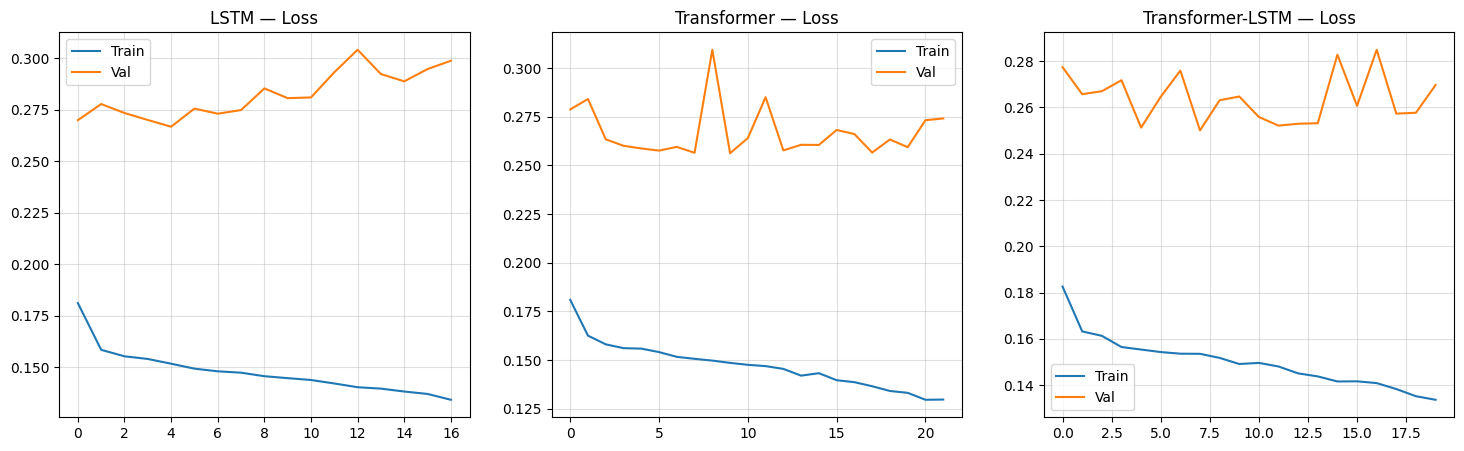

In [11]:
fig = plt.figure(figsize=(18, 5))
shown_models = ["Simple RNN", "LSTM", "Transformer", "Transformer-LSTM"]

for i, mname in enumerate(shown_models):
    ax = fig.add_subplot(1, 4, i+1)
    h = all_history[mname]
    ax.plot(h["loss"], label="Train")
    ax.plot(h["val_loss"], label="Val")
    ax.set_title(f"{mname} — Loss Curve")
    ax.legend()
    ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()


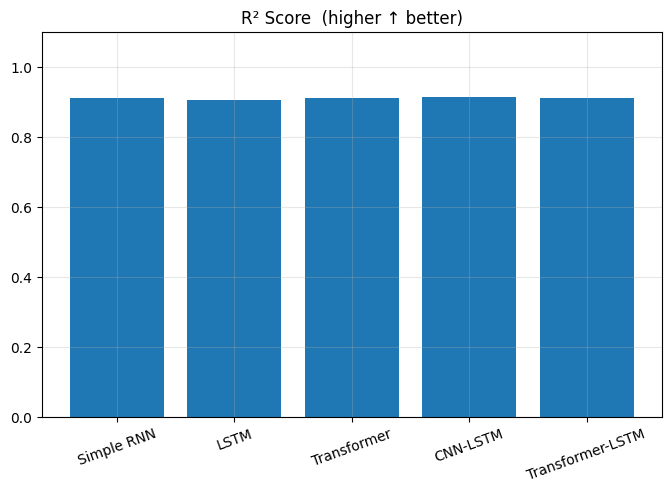

In [12]:
model_names = list(MODEL_REGISTRY.keys())
vals = [all_results[m]["R2"] for m in model_names]

colors = ["#5b8dd9" if m != "Transformer-LSTM" else "#e84c3d" for m in model_names]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, vals, color=colors)
plt.title("R² Score Comparison  (higher ↑ is better)", fontsize=13)
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1.1)
plt.axhline(vals[-1], color="#e84c3d", linestyle="--", linewidth=1, alpha=0.5)
plt.grid(axis="y", alpha=0.3)

for bar, v in zip(bars, vals):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.02,
             f"{v:.4f}", ha="center", fontsize=9)

import matplotlib.patches as mpatches
legend = [mpatches.Patch(color="#5b8dd9", label="Baseline"),
          mpatches.Patch(color="#e84c3d", label="Proposed (Transformer-LSTM)")]
plt.legend(handles=legend)
plt.tight_layout()
plt.show()


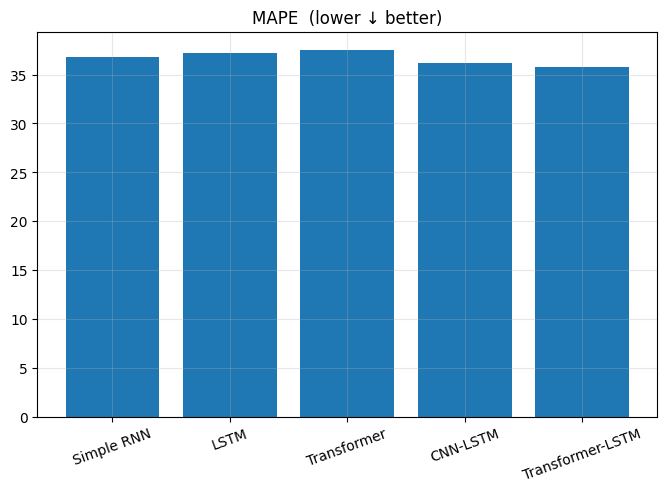

In [13]:
vals_m = [all_results[m]["MAPE"] for m in model_names]
colors = ["#5b8dd9" if m != "Transformer-LSTM" else "#e84c3d" for m in model_names]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, vals_m, color=colors)
plt.title("MAPE Comparison  (lower ↓ is better)", fontsize=13)
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)

for bar, v in zip(bars, vals_m):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.2,
             f"{v:.2f}%", ha="center", fontsize=9)

import matplotlib.patches as mpatches
legend = [mpatches.Patch(color="#5b8dd9", label="Baseline"),
          mpatches.Patch(color="#e84c3d", label="Proposed (Transformer-LSTM)")]
plt.legend(handles=legend)
plt.tight_layout()
plt.show()


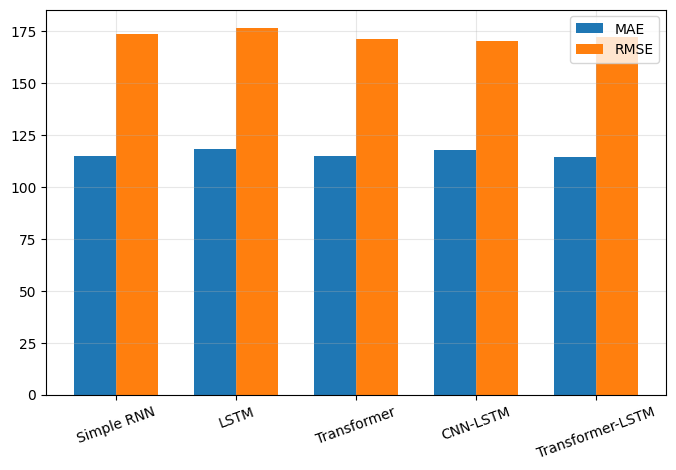

In [14]:
x      = np.arange(len(model_names))
w      = 0.35
mae_v  = [all_results[m]["MAE"]  for m in model_names]
rmse_v = [all_results[m]["RMSE"] for m in model_names]

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, mae_v,  w, label="MAE",  color="#5b8dd9")
b2 = ax.bar(x + w/2, rmse_v, w, label="RMSE", color="#2ecc71")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha="right")
ax.set_title("MAE & RMSE Comparison  (lower ↓ is better)", fontsize=13)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Highlight proposed model
ax.axvspan(len(model_names)-1 - 0.5, len(model_names)-1 + 0.5,
           alpha=0.08, color="red", label="_nolegend_")
ax.text(len(model_names)-1, max(max(mae_v), max(rmse_v))*1.01,
        "Proposed", ha="center", color="red", fontsize=9)
plt.tight_layout()
plt.show()


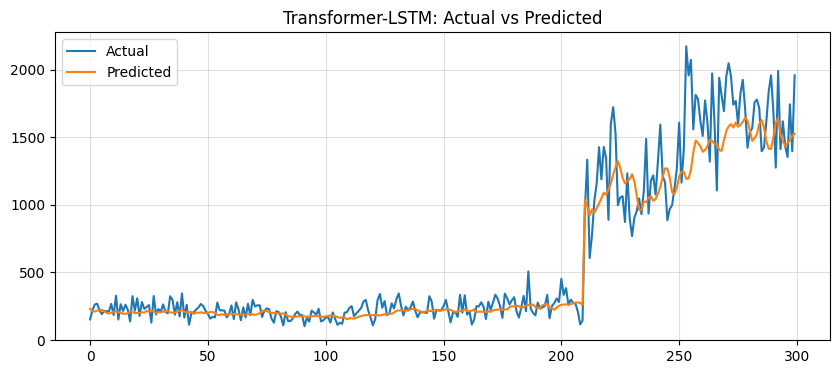

In [15]:
yt, yp = all_preds_inv["Transformer-LSTM"]
n_show = min(300, len(yt))

plt.figure(figsize=(10,4))
plt.plot(yt[:n_show], label="Actual")
plt.plot(yp[:n_show], label="Predicted")
plt.title("Transformer-LSTM: Actual vs Predicted")
plt.legend()
plt.grid(alpha=0.4)
plt.show()

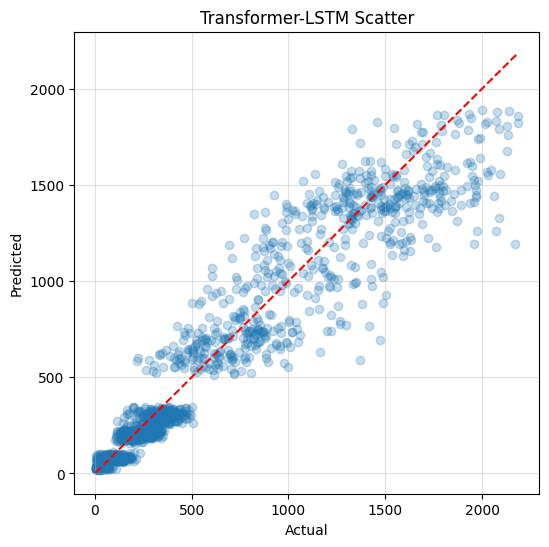

In [16]:
plt.figure(figsize=(6,6))
plt.scatter(yt, yp, alpha=0.25)
mn, mx = min(yt.min(), yp.min()), max(yt.max(), yp.max())
plt.plot([mn,mx],[mn,mx],"r--")
plt.title("Transformer-LSTM Scatter")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(alpha=0.4)
plt.show()

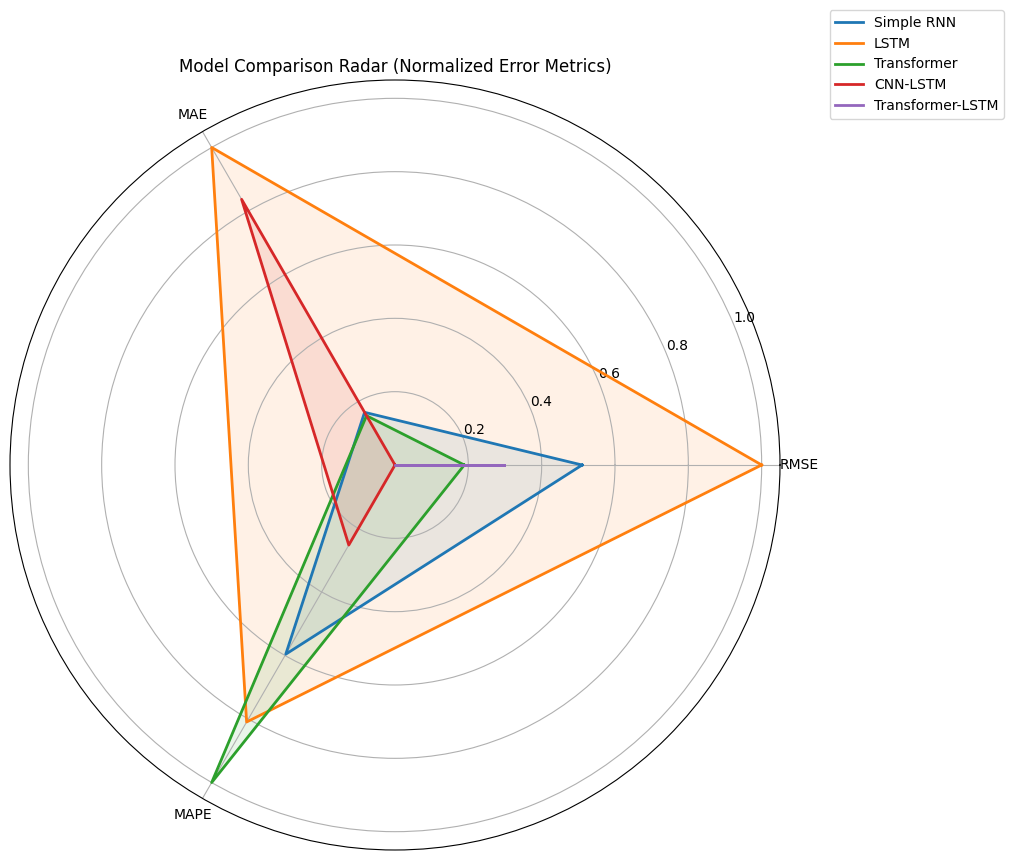

In [31]:
# ==============================================================
# RADAR CHART  (Using our model results)
# ==============================================================

# Convert all_results dict → DataFrame
comparison_df = pd.DataFrame(all_results).T.reset_index()
comparison_df.rename(columns={"index": "Model"}, inplace=True)

# Keep only error metrics (lower = better)
metrics_cols = ["RMSE", "MAE", "MAPE"]

# Normalize (Min-Max scaling)
normalized_df = comparison_df.copy()

for col in metrics_cols:
    normalized_df[col] = (
        normalized_df[col] - normalized_df[col].min()
    ) / (normalized_df[col].max() - normalized_df[col].min())

labels = metrics_cols
num_vars = len(labels)

angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

fig = plt.figure(figsize=(10,10))
ax = plt.subplot(111, polar=True)

for i, row in normalized_df.iterrows():
    values = row[metrics_cols].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title("Model Comparison Radar (Normalized Error Metrics)")
plt.legend(loc="upper right", bbox_to_anchor=(1.3,1.1))

plt.show()

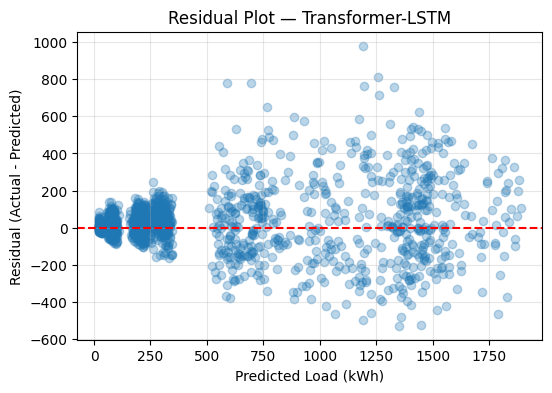

In [32]:
# ==============================================================
# RESIDUAL PLOT
# ==============================================================

residuals = y_true - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.3)

plt.axhline(0, color="red", linestyle="--")
plt.title("Residual Plot — Transformer-LSTM")
plt.xlabel("Predicted Load (kWh)")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(alpha=0.3)

plt.show()

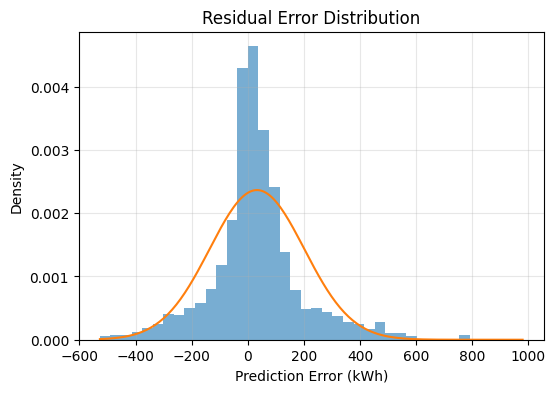

In [33]:
# ==============================================================
# RESIDUAL ERROR DISTRIBUTION
# ==============================================================

plt.figure(figsize=(6,4))

# Histogram
count, bins, _ = plt.hist(residuals, bins=40, density=True, alpha=0.6)

# Gaussian fit (smooth curve)
mean = np.mean(residuals)
std  = np.std(residuals)
x = np.linspace(min(bins), max(bins), 200)
pdf = (1/(std*np.sqrt(2*np.pi))) * np.exp(-(x-mean)**2/(2*std**2))

plt.plot(x, pdf)

plt.title("Residual Error Distribution")
plt.xlabel("Prediction Error (kWh)")
plt.ylabel("Density")
plt.grid(alpha=0.3)

plt.show()

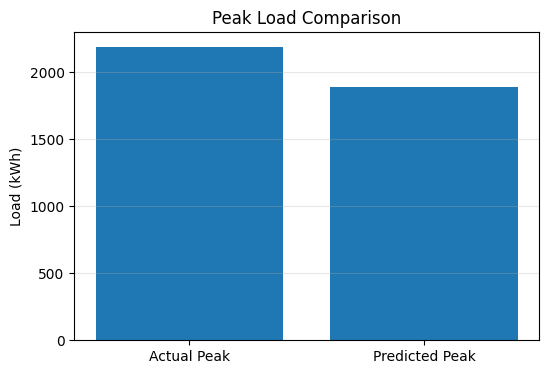

Actual Peak     : 2187.05 kWh
Predicted Peak  : 1891.43 kWh


In [34]:
# ==============================================================
# PEAK LOAD COMPARISON
# ==============================================================

actual_peak = np.max(y_true)
pred_peak   = np.max(y_pred)

plt.figure(figsize=(6,4))

plt.bar(["Actual Peak", "Predicted Peak"],
        [actual_peak, pred_peak])

plt.title("Peak Load Comparison")
plt.ylabel("Load (kWh)")
plt.grid(axis="y", alpha=0.3)

plt.show()

print(f"Actual Peak     : {actual_peak:.2f} kWh")
print(f"Predicted Peak  : {pred_peak:.2f} kWh")

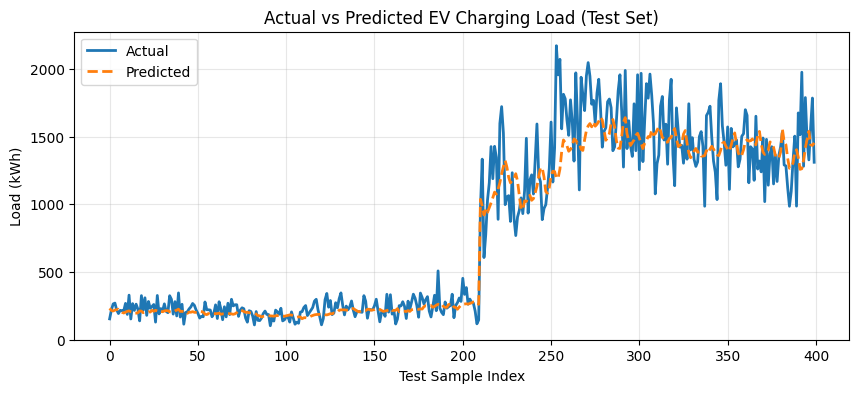

In [35]:
# ==============================================================
# ACTUAL vs PREDICTED LOAD
# ==============================================================

plt.figure(figsize=(10,4))

n_show = min(400, len(y_true))

plt.plot(y_true[:n_show], label="Actual", linewidth=2)
plt.plot(y_pred[:n_show], linestyle="--", label="Predicted", linewidth=2)

plt.title("Actual vs Predicted EV Charging Load (Test Set)")
plt.xlabel("Test Sample Index")
plt.ylabel("Load (kWh)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

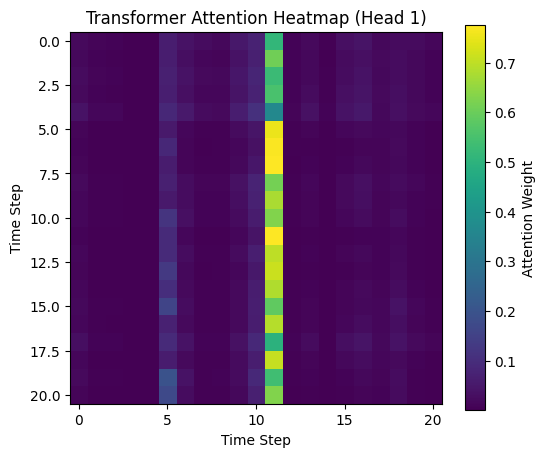

In [41]:
# ==============================================================
# EXTRACT ATTENTION WEIGHTS (SAFE VERSION)
# ==============================================================

def get_attention_weights(model, x):
    model.eval()
    
    # First project + positional encoding
    x = model.pe(model.proj(x))
    
    # Take first encoder layer
    layer = model.transformer.layers[0]
    
    # Manually call self-attention with need_weights=True
    attn_output, attn_weights = layer.self_attn(
        x, x, x,
        need_weights=True,
        average_attn_weights=False
    )
    
    return attn_weights  # shape: (batch, heads, seq_len, seq_len)



xb_sample, _ = next(iter(test_loader))
xb_sample = xb_sample[:1].to(DEVICE)

attn_weights = get_attention_weights(loaded_model, xb_sample)

# Take first head
attn = attn_weights[0, 0].detach().cpu().numpy()

plt.figure(figsize=(6,5))
plt.imshow(attn, cmap="viridis")
plt.colorbar(label="Attention Weight")

plt.title("Transformer Attention Heatmap (Head 1)")
plt.xlabel("Time Step")
plt.ylabel("Time Step")

plt.show()

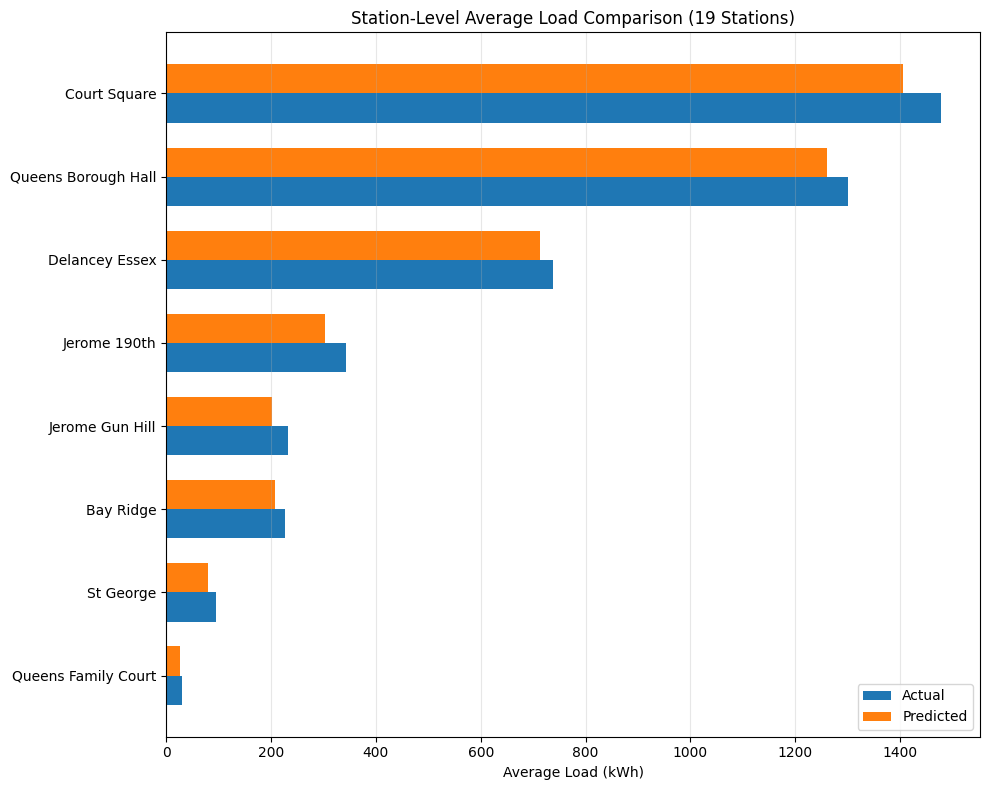

In [40]:
# ==============================================================
# STATION-LEVEL LOAD COMPARISON (19 Stations - Clean View)
# ==============================================================

station_results = {}

idx = 0
for loc in loc_list_sorted:
    n_seq = test_counts[loc]
    if n_seq == 0:
        continue
    
    station_true = y_true[idx:idx+n_seq]
    station_pred = y_pred[idx:idx+n_seq]
    
    station_results[loc] = {
        "Actual": np.mean(station_true),
        "Predicted": np.mean(station_pred)
    }
    
    idx += n_seq

station_df = pd.DataFrame(station_results).T

# Sort by actual load
station_df = station_df.sort_values("Actual")

# --------------------------------------------------------------

plt.figure(figsize=(10,8))

y_pos = np.arange(len(station_df))
h = 0.35

plt.barh(y_pos - h/2, station_df["Actual"], h, label="Actual")
plt.barh(y_pos + h/2, station_df["Predicted"], h, label="Predicted")

plt.yticks(y_pos, station_df.index)
plt.xlabel("Average Load (kWh)")
plt.title("Station-Level Average Load Comparison (19 Stations)")
plt.legend()
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
df_res = pd.DataFrame(all_results).T.round(4)
df_res.index.name = "Model"
df_res.columns    = ["R² Score", "MAE (kWh)", "RMSE (kWh)", "MAPE (%)"]
df_res["Rank"]    = df_res["R² Score"].rank(ascending=False).astype(int)
df_res.sort_values("Rank", inplace=True)

df_res.to_csv("model_comparison_results.csv")
print("\nFinal Model Comparison Table:")
print(df_res.to_string())
print("\nTable saved → model_comparison_results.csv")
print("\n✅ All baseline models trained and compared with Proposed Transformer-LSTM!")


Table saved → model_comparison_results.csv
All models trained and compared!
